In [19]:
!pip install reportlab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import nbformat
from nbformat.v4 import new_notebook, new_markdown_cell, new_code_cell
from pathlib import Path
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
import os


# ---------------------- User-adjustable paths ----------------------
CSV_PATH = "Cardiotocographic.csv"   # change if file in different location
OUT_DIR = "eda_outputs"
PLOT_DIR = os.path.join(OUT_DIR, "eda_plots")
NOTEBOOK_PATH = os.path.join(OUT_DIR, "EDA_Cardiotocographic.ipynb")
SCRIPT_PATH = os.path.join(OUT_DIR, "EDA_Cardiotocographic.py")
CLEANED_CSV = os.path.join(OUT_DIR, "Cardiotocographic_cleaned.csv")
PDF_PATH = os.path.join(OUT_DIR, "EDA_Report_Cardiotocographic.pdf")
# -------------------------------------------------------------------

import pandas as pd

df = pd.read_csv("Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [20]:
os.makedirs(PLOT_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(CSV_PATH)
# Trim whitespace in column names
df.columns = [c.strip() for c in df.columns]

# Attempt numeric conversion for columns that look numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Basic info
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# Statistical summary
desc = df.describe(include='all').transpose()
print("\nDescriptive statistics for numeric columns:")
print(desc.loc[desc.index.intersection(df.select_dtypes(include=[np.number]).columns)])

# Numeric columns list
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)

# Outlier detection (IQR method)
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = int(df[(df[col] < lower) | (df[col] > upper)].shape[0])
    outlier_summary[col] = {"count": count, "lower": float(lower), "upper": float(upper)}
print("\nOutlier summary (IQR method):")
for k,v in outlier_summary.items():
    print(f" - {k}: count={v['count']}, lower={v['lower']}, upper={v['upper']}")

# Correlation matrix (Pearson)
if numeric_cols:
    corr = df[numeric_cols].corr()
    print("\nTop absolute correlations (excluding self):")
    corr_unstack = corr.abs().unstack().sort_values(ascending=False)
    corr_unstack = corr_unstack[corr_unstack < 0.9999]  # remove self
    top = corr_unstack.drop_duplicates().head(10)
    for idx, val in top.items():
        print(f" {idx[0]} vs {idx[1]} : {val:.3f}")
else:
    corr = pd.DataFrame()


/tmp/ipython-input-4038992057.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


Shape: (2126, 14)

Column dtypes:
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

Missing values per column:
LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Descriptive statistics for numeric columns:
           count        mean        std         min         25%         50%  \
LB        2105.0  133.343598  11.270154   51.842487  126.000000  133.000000   
AC        2106.0    0.003219   0.004391   -0.019284    0.000000    0.001634   
FM        2126.0    0.009894   0.067540   -0.480634    0.000000    0.000000   
UC        2126.0    0.004391   0.003340   -0.014925    0.001

In [34]:
# ------------------------- Visualizations -------------------------
# 1. Histograms & boxplots for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].plot(kind='hist', bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"hist_{col}.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(6,4))
    df[col].plot(kind='box')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"box_{col}.png"), dpi=150)
    plt.close()

In [22]:
# 2. Scatter matrix (sampled to avoid very large images)
if len(numeric_cols) > 1:
    sample_df = df[numeric_cols].sample(n=min(200, len(df)), random_state=42)
    axes = scatter_matrix(sample_df, diagonal='hist', figsize=(10,10))
    plt.suptitle("Scatter Matrix (sampled)", y=0.92)
    plt.savefig(os.path.join(PLOT_DIR, "scatter_matrix.png"), dpi=150)
    plt.close()

In [23]:
# 3. Correlation image using imshow
if not corr.empty:
    plt.figure(figsize=(8,6))
    im = plt.imshow(corr.values, interpolation='nearest')
    plt.colorbar(im)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation matrix (Pearson)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "correlation_matrix.png"), dpi=150)
    plt.close()

In [24]:
# 4. Violin plots by a label if a likely label column exists
possible_labels = [c for c in df.columns if c.lower() in ['class','fetal_health','fetalhealth','status','health']]
if possible_labels:
    label_col = possible_labels[0]
    groups = df[label_col].dropna().unique()
    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        data = [df[df[label_col]==g][col].dropna().values for g in groups]
        if any(len(d)==0 for d in data):
            continue
        plt.violinplot(data, showmeans=True)
        plt.title(f"Violin plot of {col} by {label_col}")
        plt.xlabel(label_col)
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, f"violin_{col}_by_{label_col}.png"), dpi=150)
        plt.close()

In [27]:
# ============================
# FULL EDA FOR CARDIOTOCOGRAPHIC DATASET
# With Working Visualizations
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from IPython.display import Image, display
import os

# ---------------------- Paths ----------------------
CSV_PATH = "Cardiotocographic.csv"     # change if needed
OUT_DIR = "eda_outputs"
PLOT_DIR = os.path.join(OUT_DIR, "eda_plots")

os.makedirs(PLOT_DIR, exist_ok=True)

# ---------------------- Load Dataset ----------------------
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]   # clean column names

# Convert numeric-looking columns
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Statistical Summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe()
print("\nStatistical Summary:\n", desc)

# ---------------------- Outlier Detection ----------------------
print("\nOutlier Detection (IQR Method):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

# ---------------------- Visualization Section ----------------------
print("\nGenerating Visualizations...\n")

Dataset Shape: (2126, 14)

Data Types:
 LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

Missing Values:
 LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Statistical Summary:
                 LB           AC           FM           UC           DL  \
count  2105.000000  2106.000000  2126.000000  2126.000000  2126.000000   
mean    133.343598     0.003219     0.009894     0.004391     0.001895   
std      11.270154     0.004391     0.067540     0.003340     0.003343   
min      51.842487    -0.019284    -0.480634    -0.014925    -0.015393   
25%     126.000000     0.000000 

/tmp/ipython-input-4283148791.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


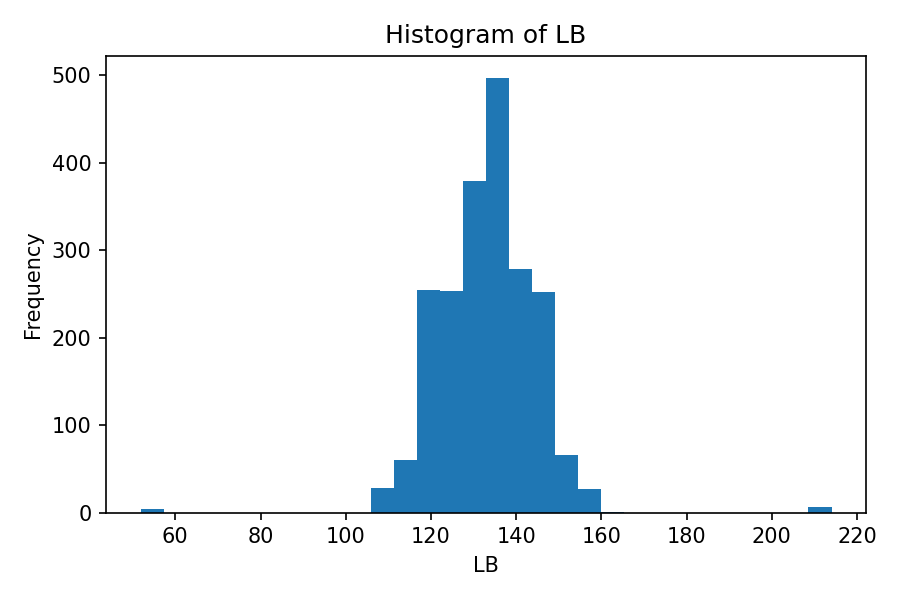

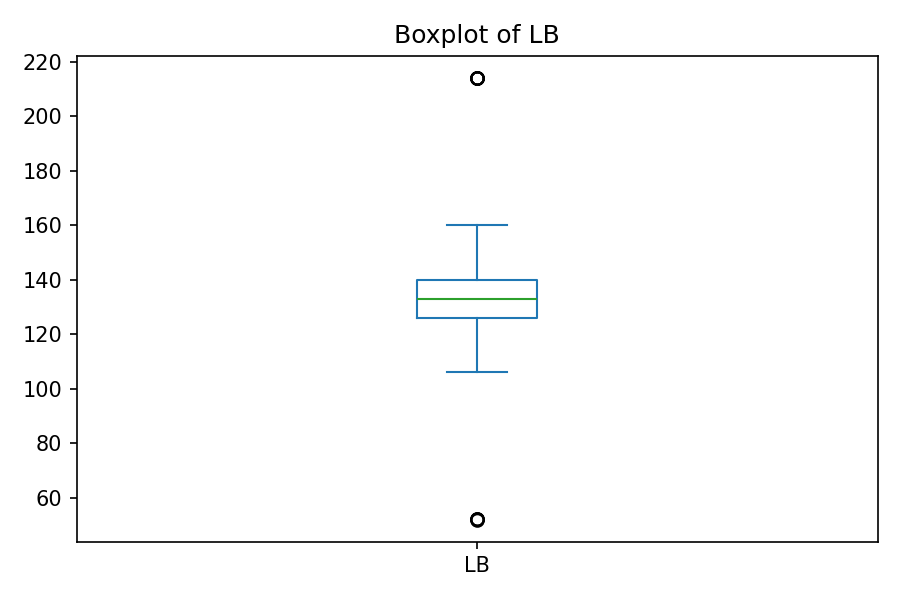

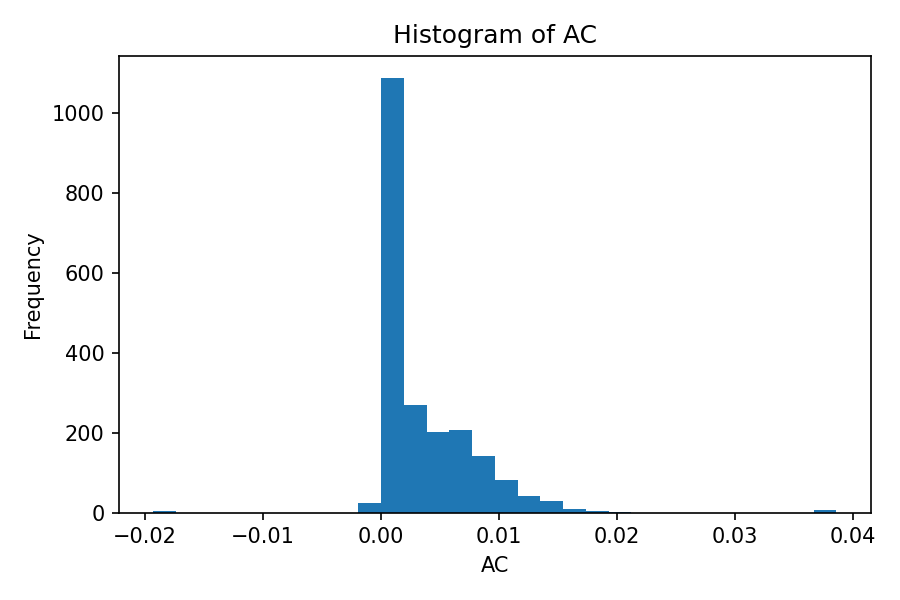

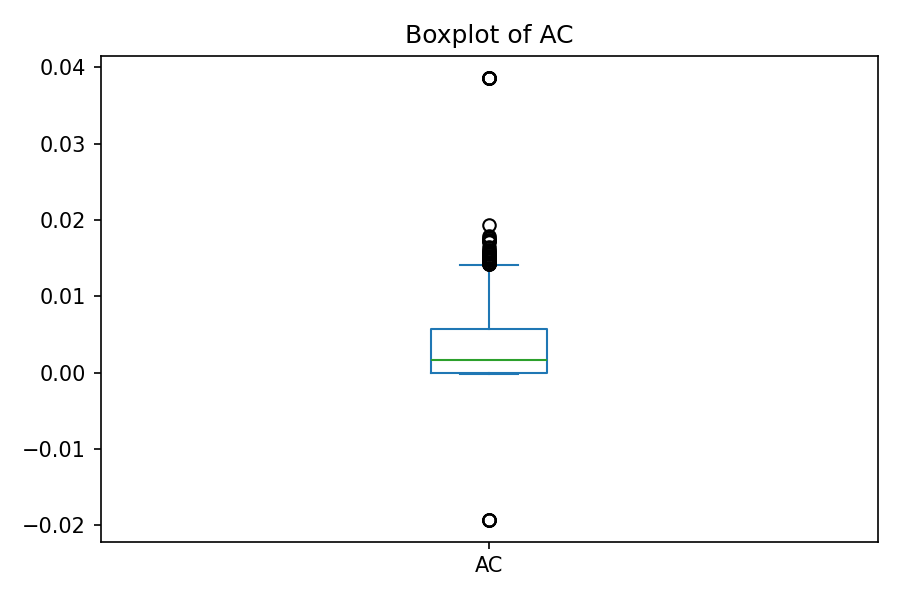

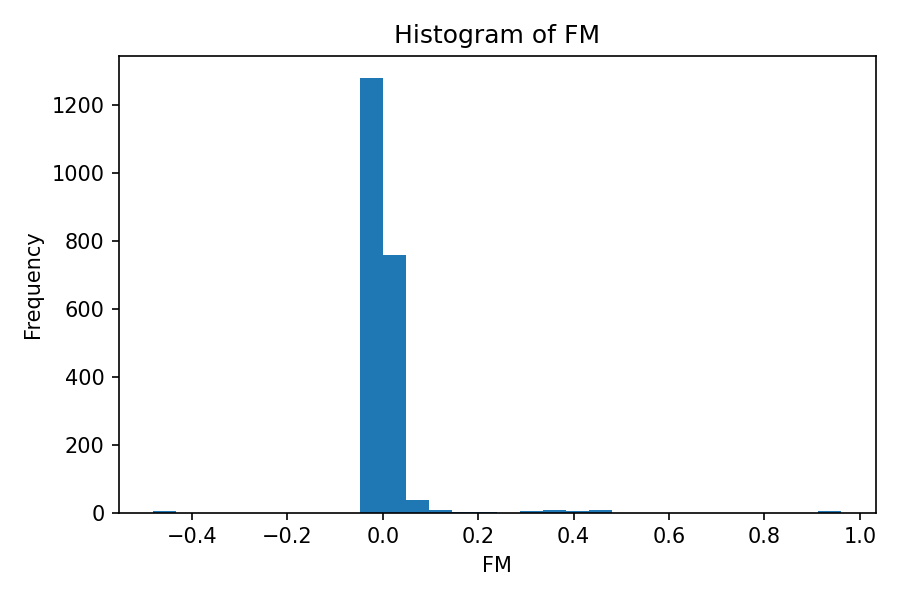

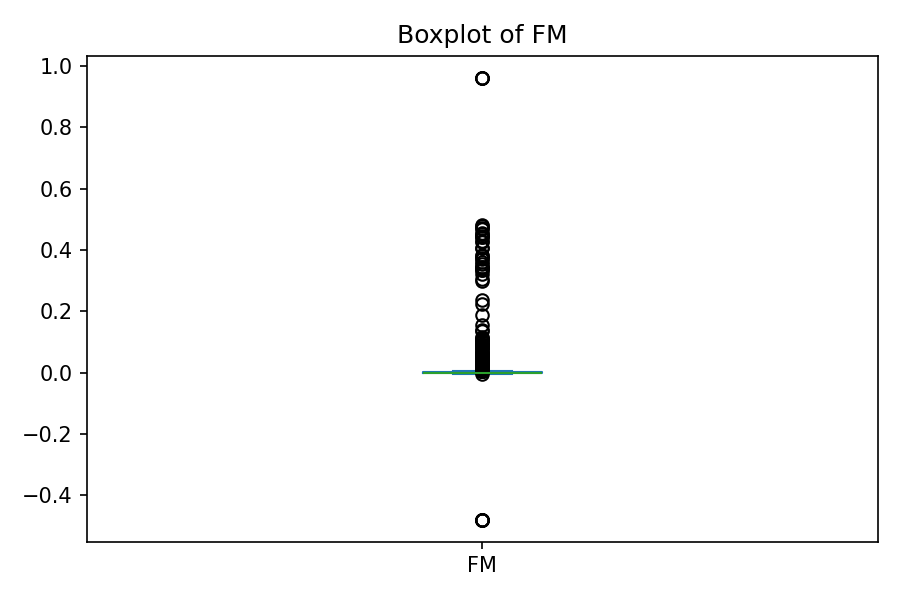

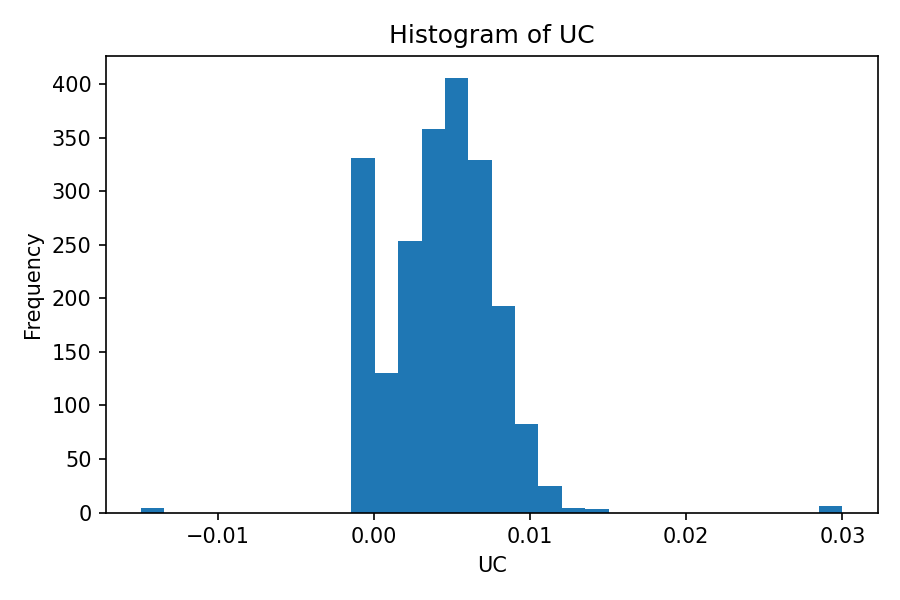

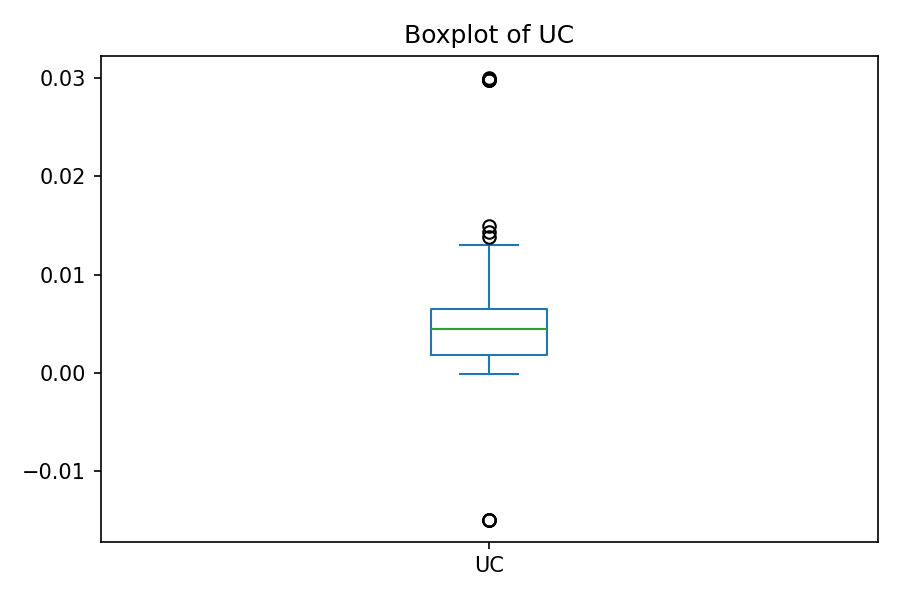

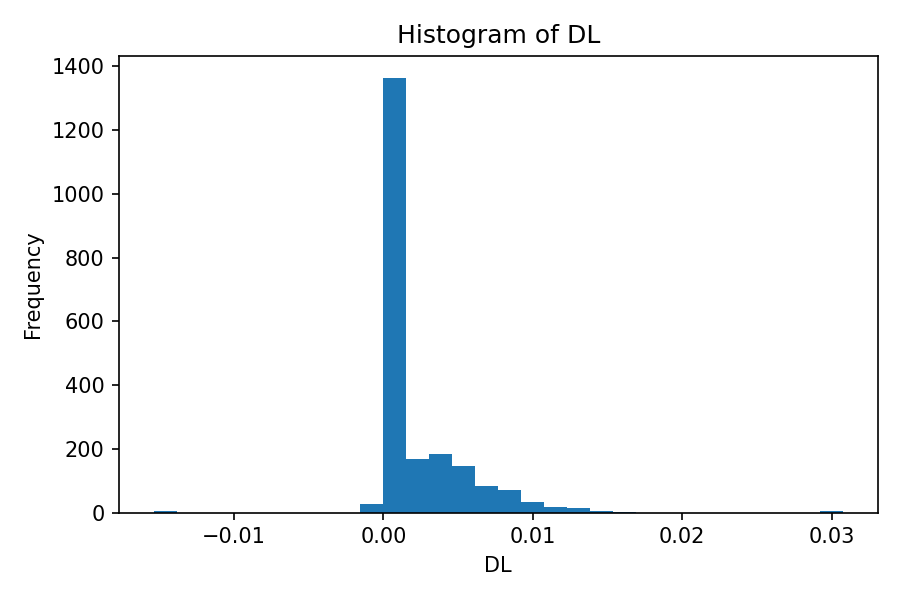

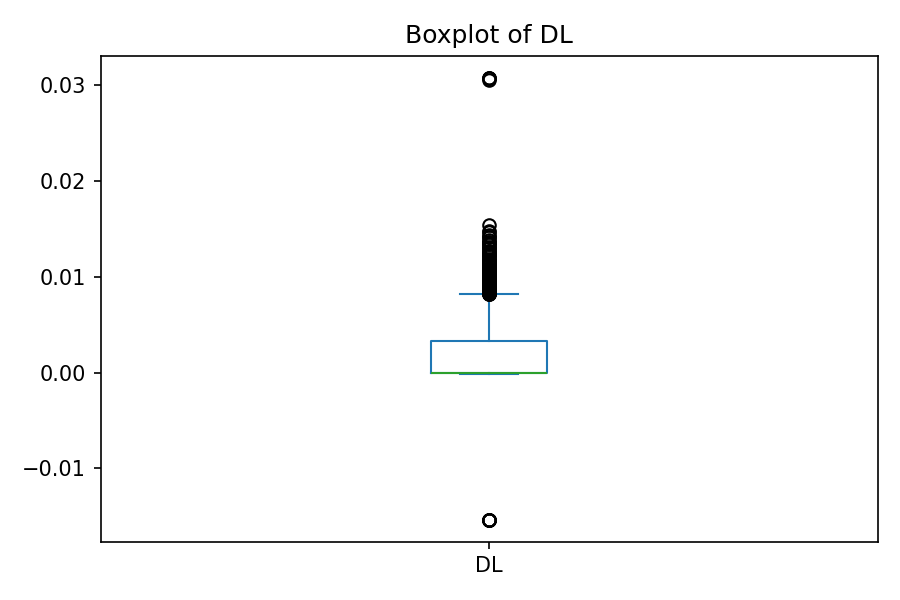

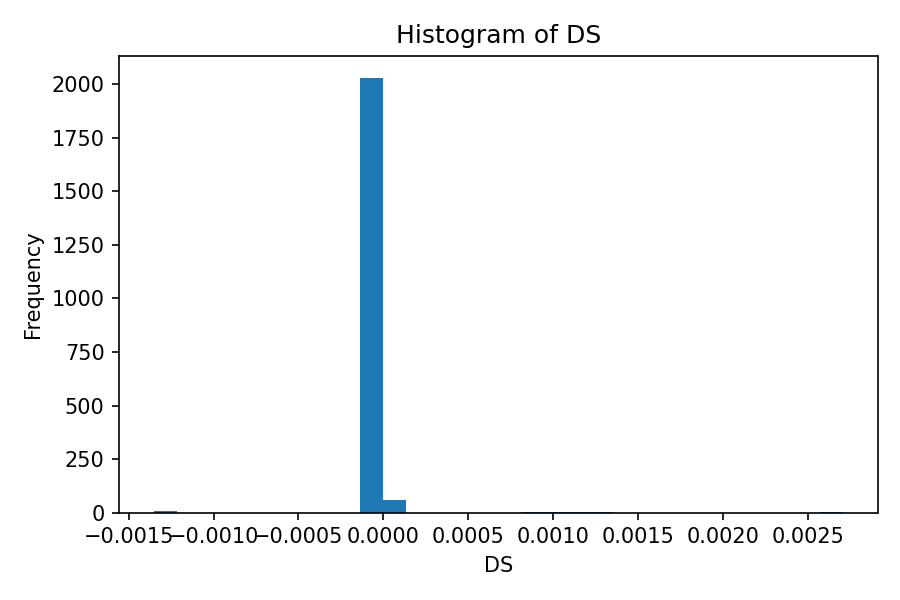

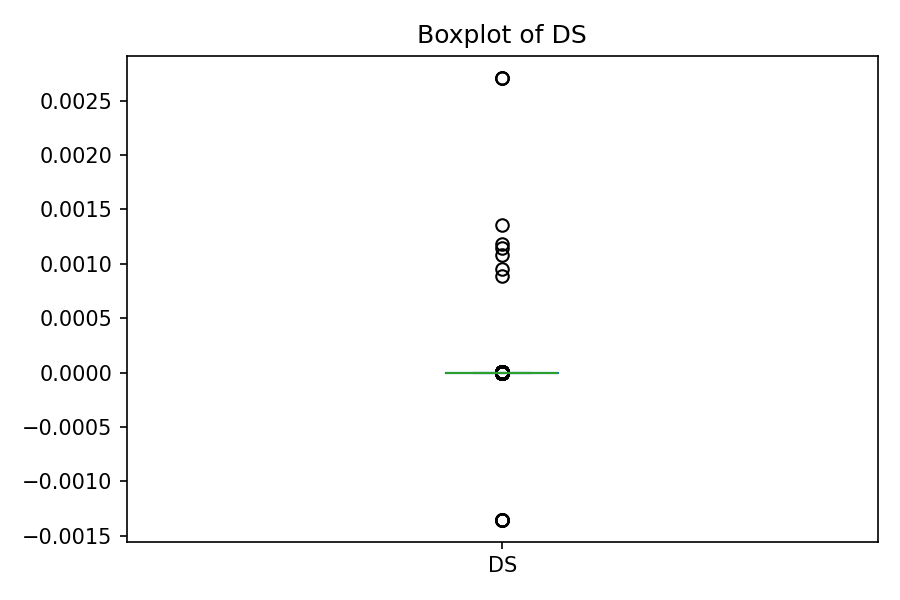

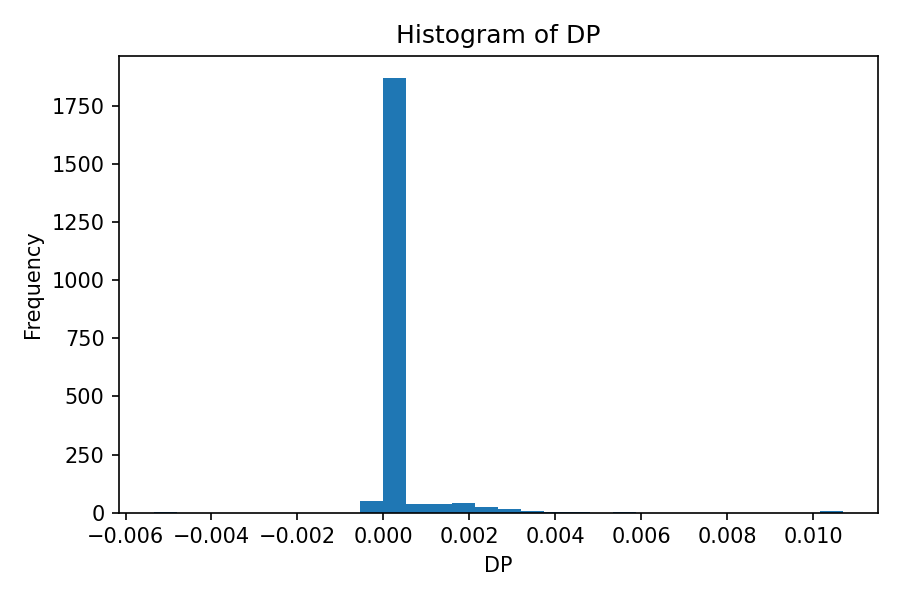

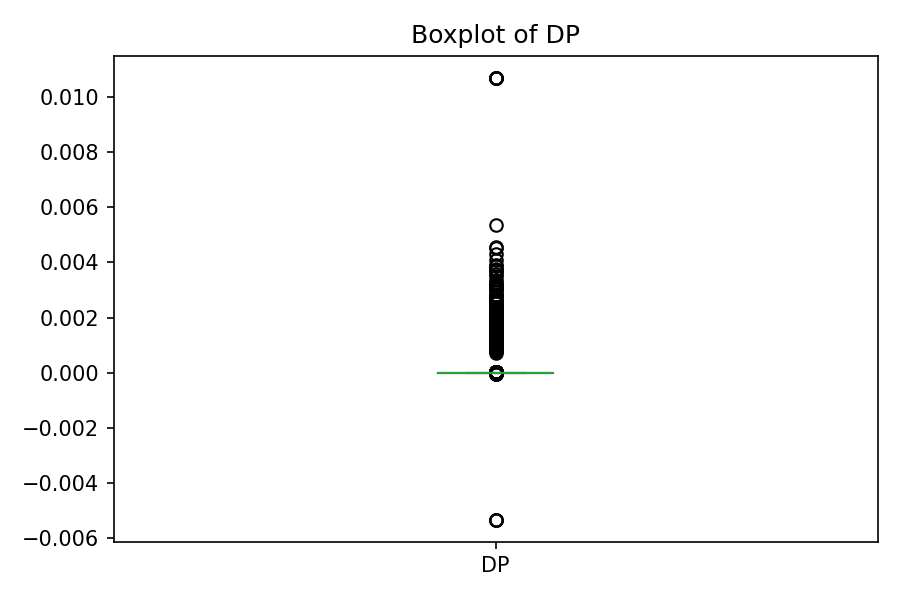

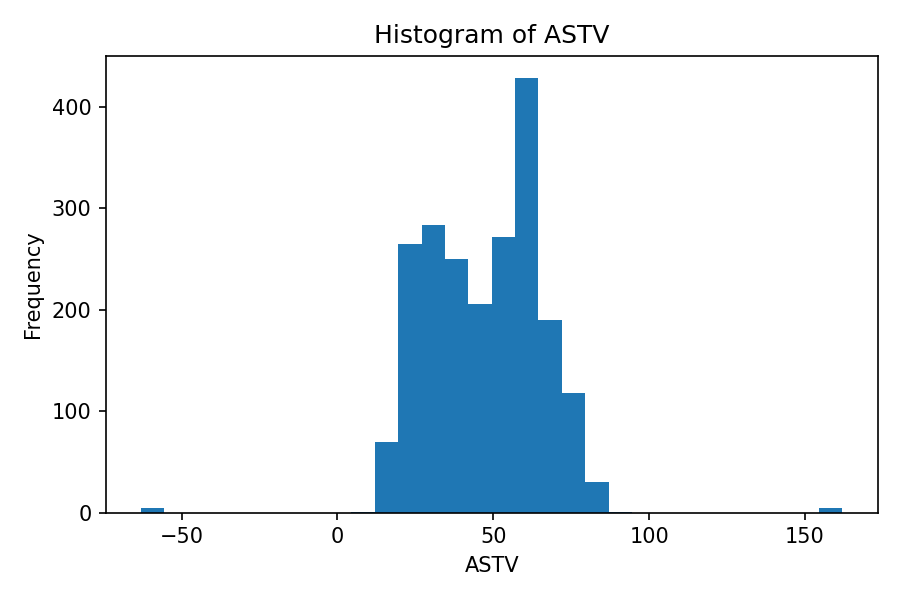

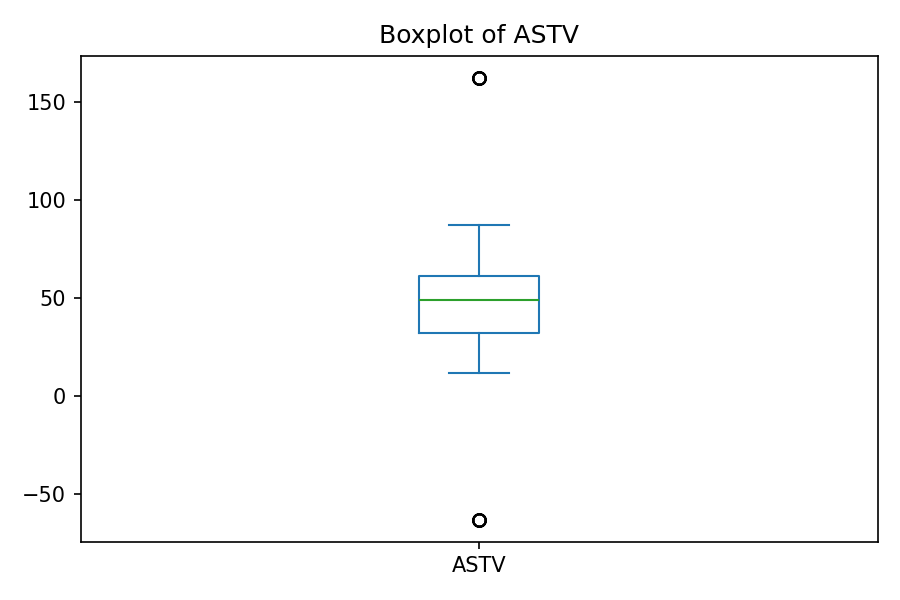

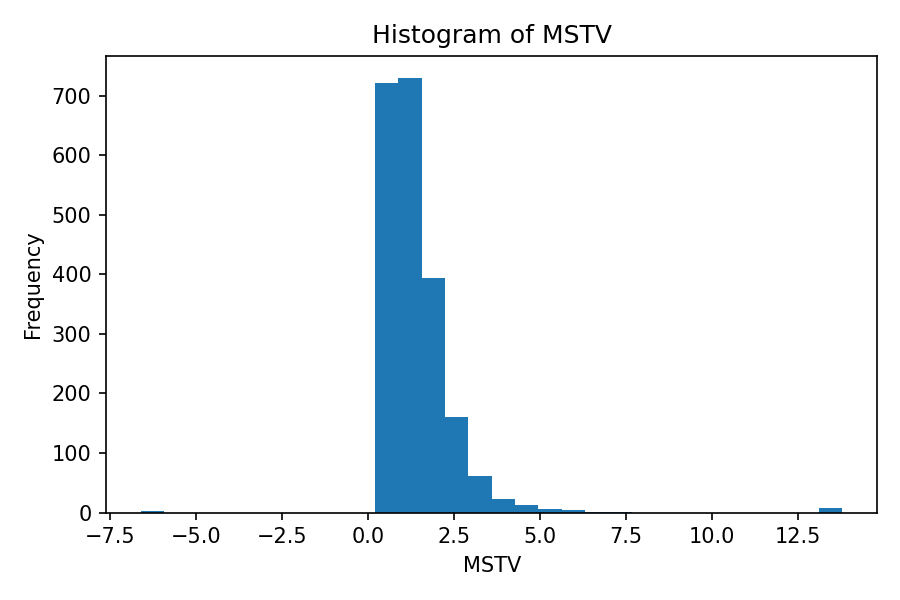

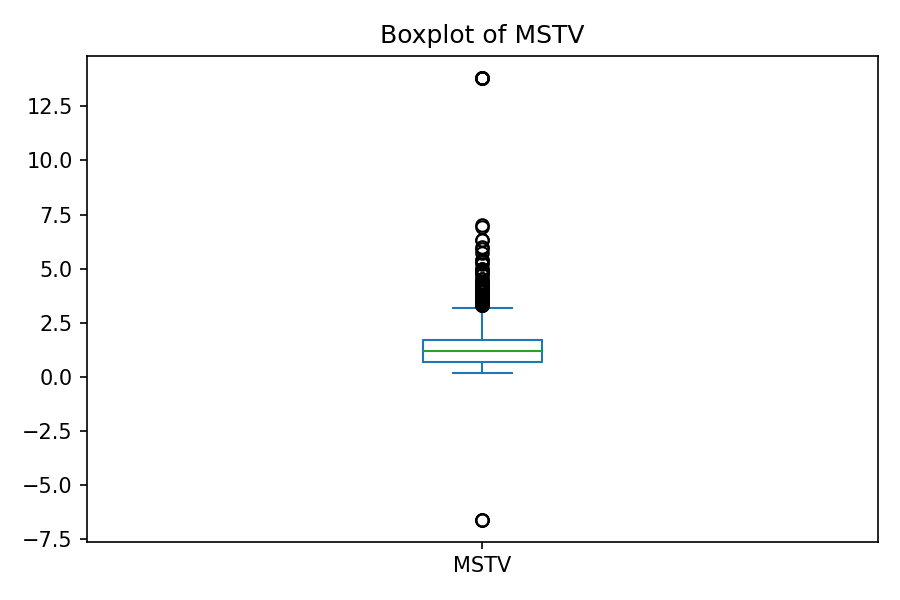

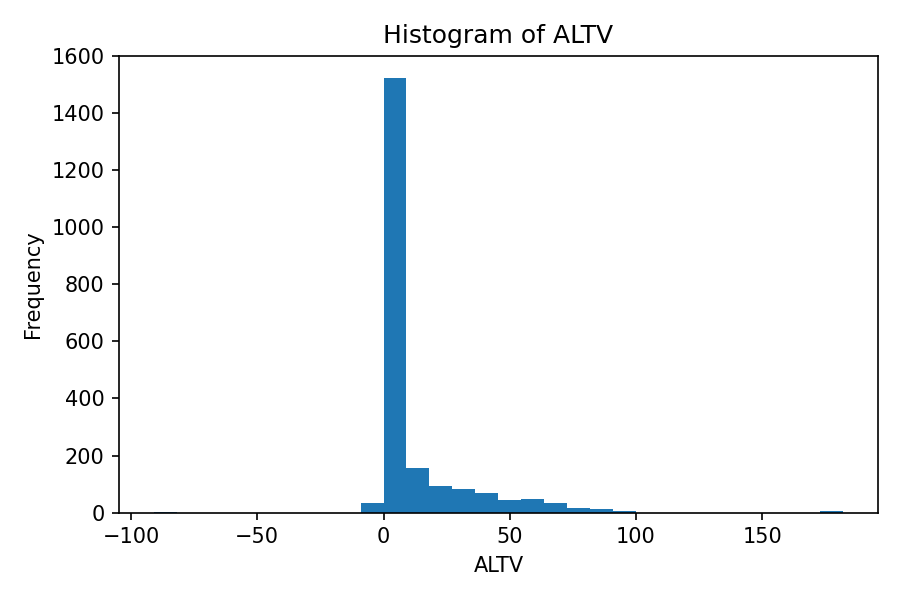

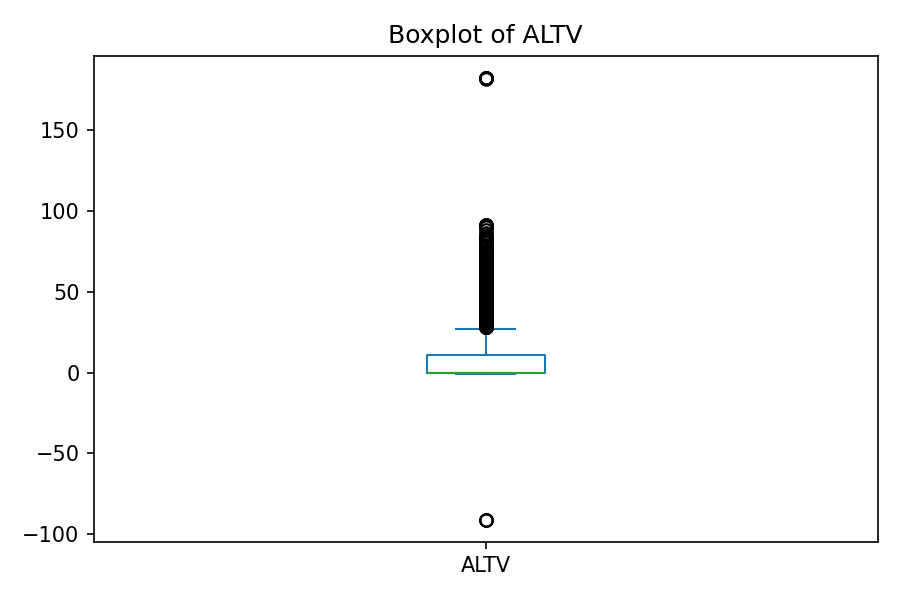

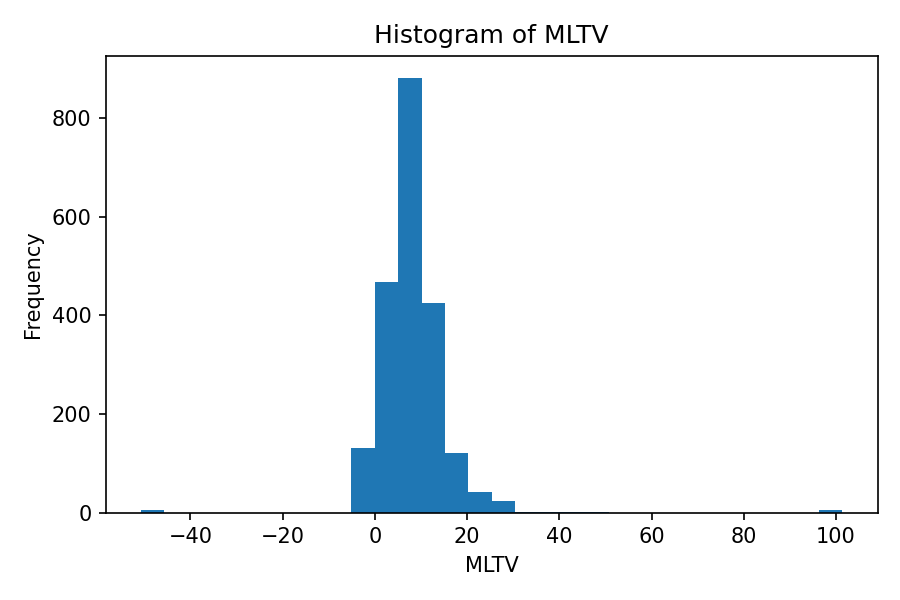

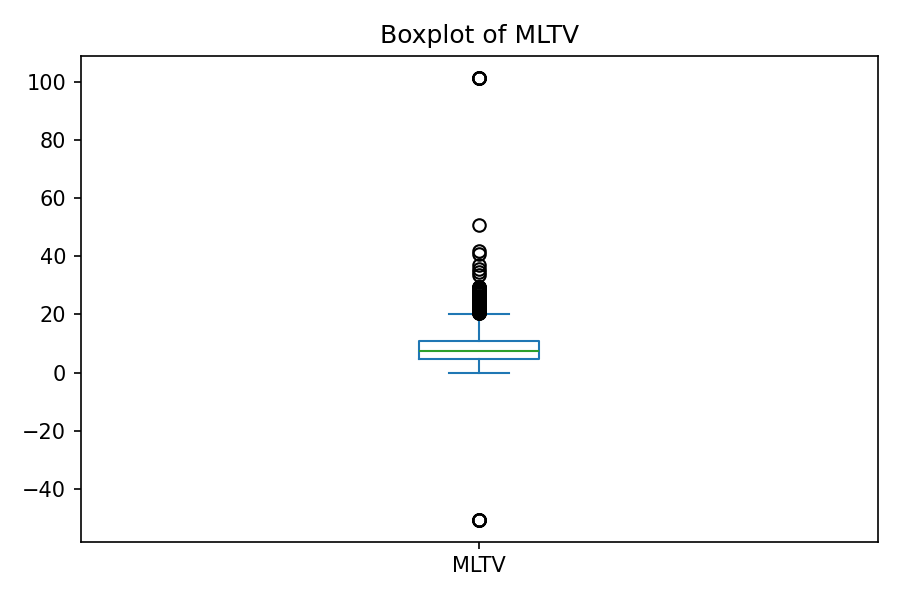

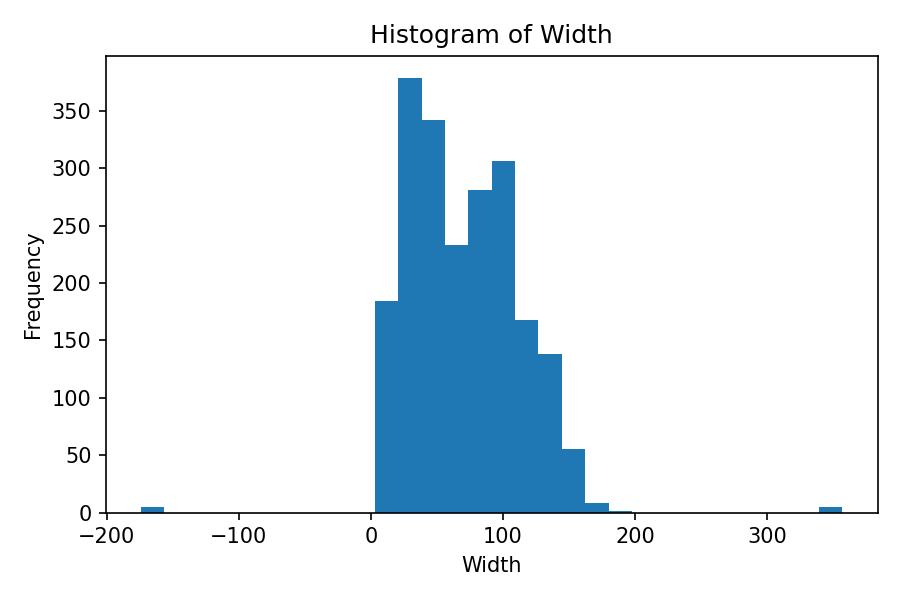

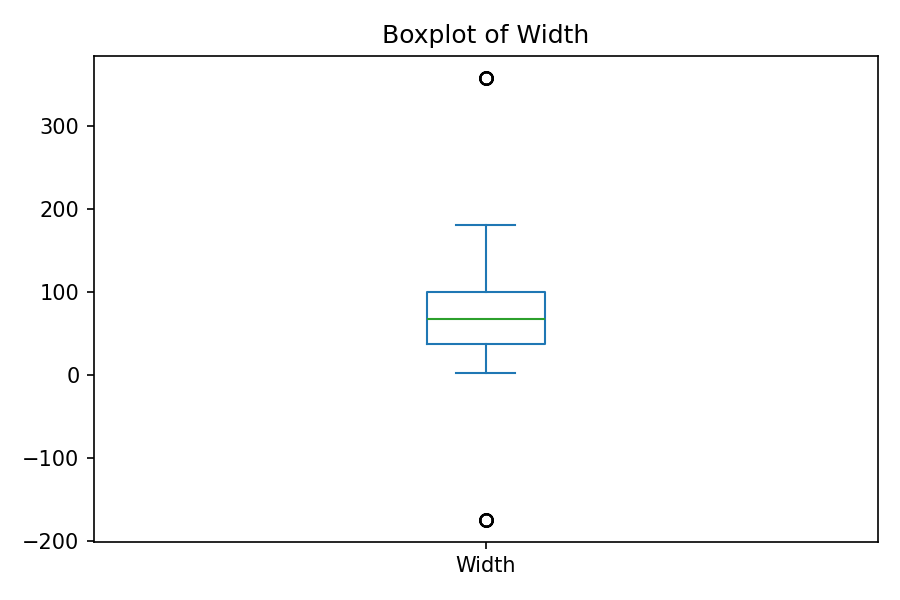

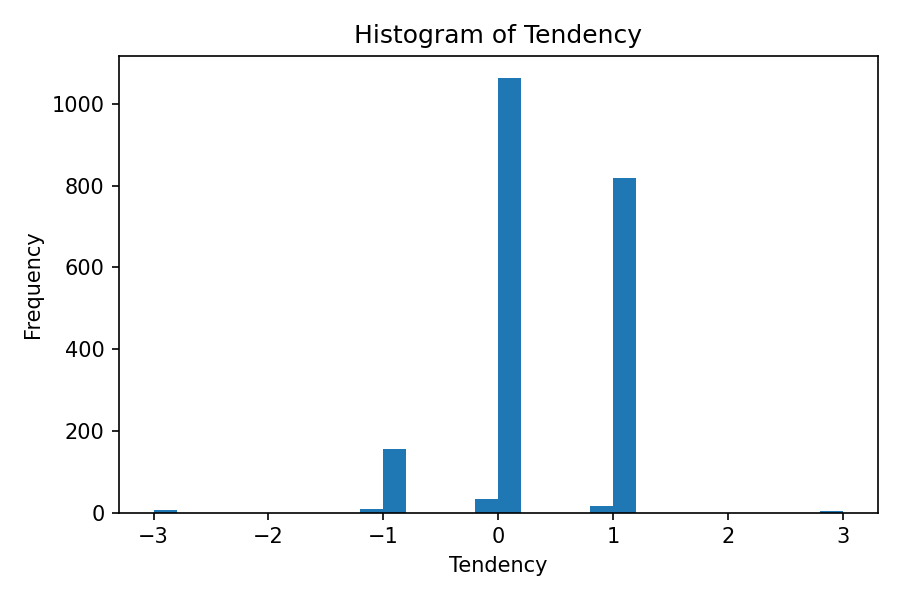

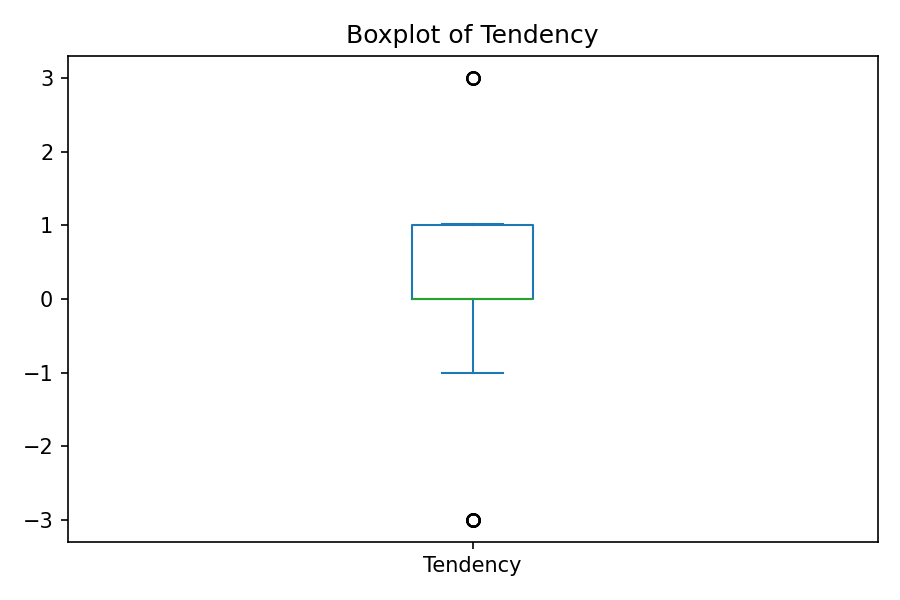

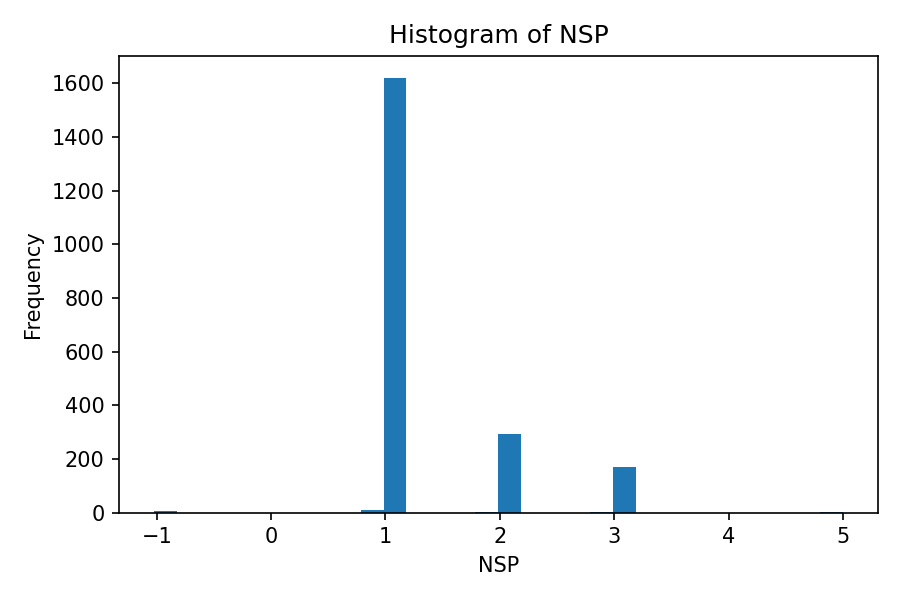

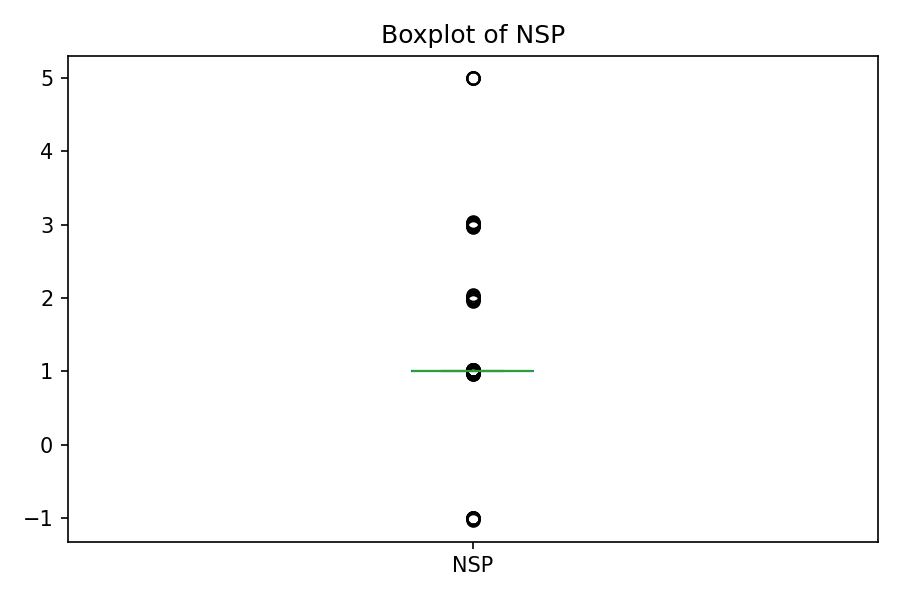

In [28]:
# 1️⃣ Histograms & Boxplots (Displayed + Saved)
for col in numeric_cols:
    # Histogram
    plt.figure(figsize=(6,4))
    df[col].plot(kind='hist', bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    hist_path = os.path.join(PLOT_DIR, f"hist_{col}.png")
    plt.savefig(hist_path, dpi=150)
    plt.close()
    display(Image(filename=hist_path))   # SHOW IMAGE

    # Boxplot
    plt.figure(figsize=(6,4))
    df[col].plot(kind='box')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    box_path = os.path.join(PLOT_DIR, f"box_{col}.png")
    plt.savefig(box_path, dpi=150)
    plt.close()
    display(Image(filename=box_path))   # SHOW IMAGE

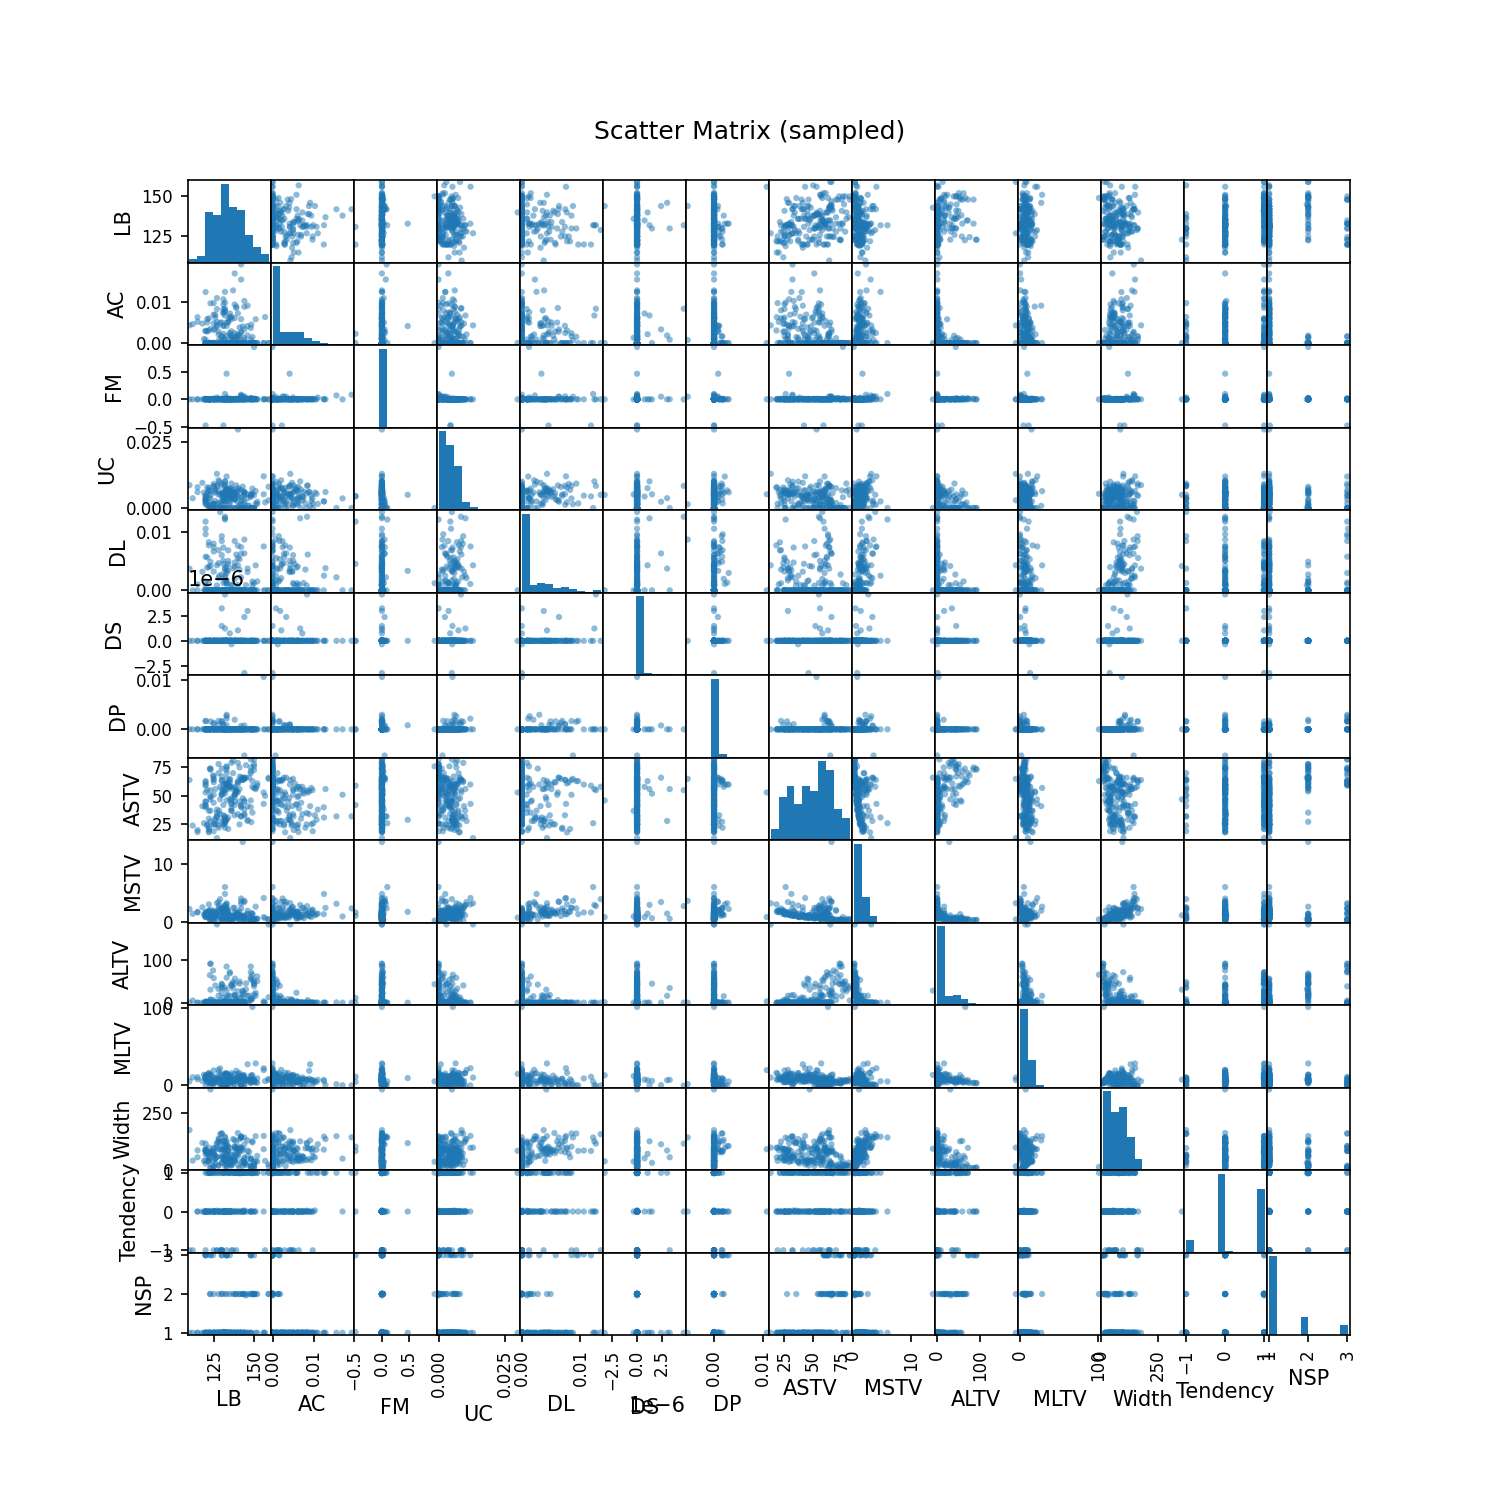

In [30]:
 #2️⃣ Scatter Matrix (Displayed + Saved)
if len(numeric_cols) > 1:
    sample_df = df[numeric_cols].sample(
        n=min(200, len(df)),
        random_state=42
    )
    axes = scatter_matrix(sample_df, figsize=(10,10), diagonal='hist')
    plt.suptitle("Scatter Matrix (sampled)", y=0.92)
    scatter_path = os.path.join(PLOT_DIR, "scatter_matrix.png")
    plt.savefig(scatter_path, dpi=150)
    plt.close()
    display(Image(filename=scatter_path))  # SHOW IMAGE

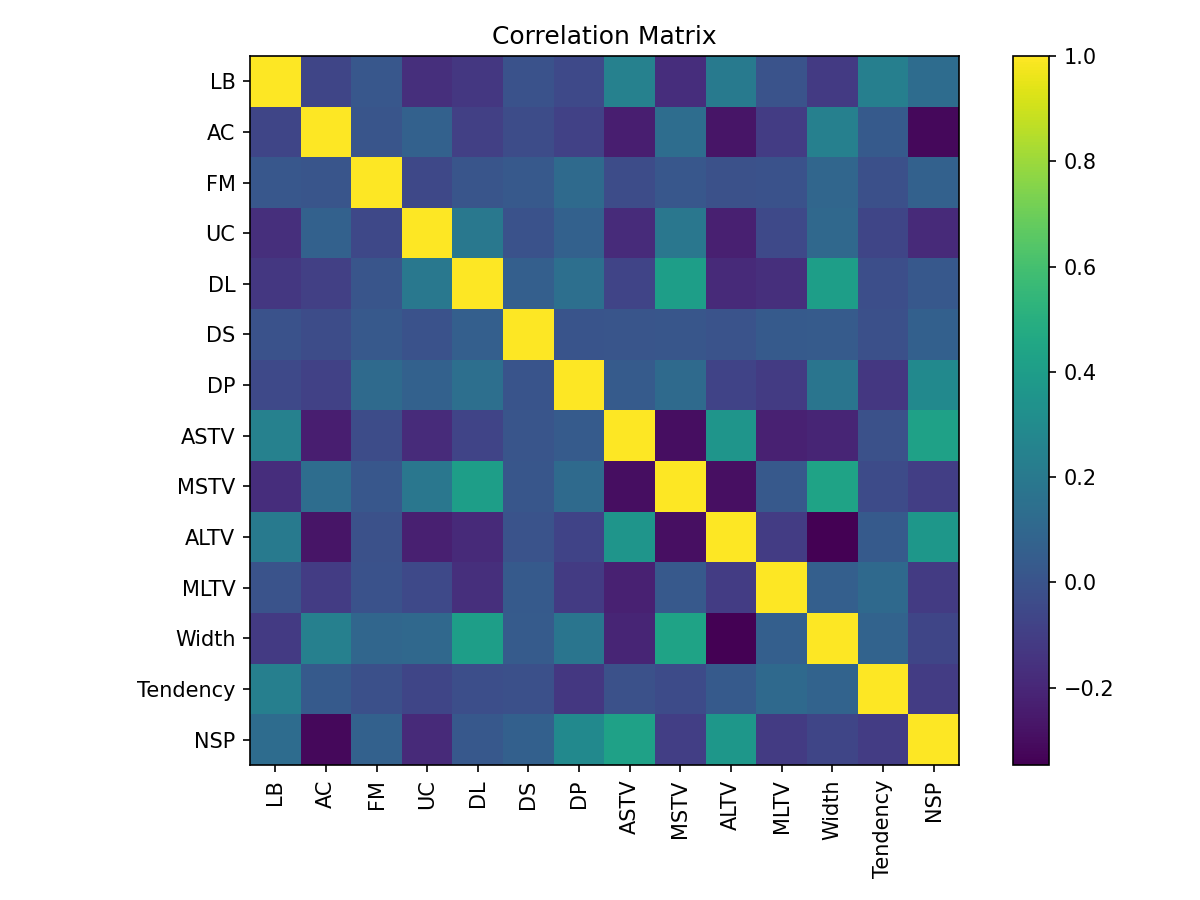

In [31]:
# 3️⃣ Correlation Heatmap (Displayed + Saved)
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
im = plt.imshow(corr.values, interpolation='nearest')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
corr_path = os.path.join(PLOT_DIR, "correlation_matrix.png")
plt.savefig(corr_path, dpi=150)
plt.close()
display(Image(filename=corr_path))   # SHOW IMAGE

In [33]:
# 4️⃣ Violin plots (if a label exists)
possible_labels = [c for c in df.columns if c.lower() in ['class','fetal_health','fetalhealth','status','health']]
if possible_labels:
    label_col = possible_labels[0]
    groups = df[label_col].dropna().unique()

    print(f"\nCreating Violin Plots (grouped by {label_col})...\n")
    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        data = [df[df[label_col] == g][col].dropna() for g in groups]

        if all(len(d) > 0 for d in data):
            plt.violinplot(data, showmeans=True)
            plt.title(f"Violin Plot of {col} by {label_col}")
            plt.xlabel(label_col)
            plt.ylabel(col)
            plt.tight_layout()
            violin_path = os.path.join(PLOT_DIR, f"violin_{col}.png")
            plt.savefig(violin_path, dpi=150)
            plt.close()
            display(Image(filename=violin_path))  # SHOW IMAGE

            # ---------------------- Save Cleaned CSV ----------------------
df_clean = df.fillna(df.median(numeric_only=True))
df_clean.to_csv(CLEANED_CSV, index=False)
print("\nCleaned dataset saved to:", CLEANED_CSV)

print("\n>>> ALL VISUALIZATIONS GENERATED SUCCESSFULLY! <<<")



Cleaned dataset saved to: eda_outputs/Cardiotocographic_cleaned.csv

>>> ALL VISUALIZATIONS GENERATED SUCCESSFULLY! <<<
